# Machine Learning LAB 7: REINFORCEMENT LEARNING

Course 2025/26: *F. Chiariotti (notebook by P. Talli)*

The notebook contains some simple tasks about **REINFORCEMENT LEARNING**.

Complete all the **required code sections**.

### IMPORTANT for the exam:

The functions you might be required to implement in the exam will have the same signature and parameters as the ones in the labs

### Content

In this lab we will implement and test two fundamental reinforcement learning algorithms: Q-Learning and SARSA. We will use a simple cliff environment to evaluate the performance of both agents.

In [15]:
# Library imports
import numpy as np
import matplotlib.pyplot as plt
import time
rng=np.random.default_rng(seed=94)

# ---> REVIEW all already implemented functions?

In [10]:
# Define a class for the Environment
class SimpleCliffEnv:
    def __init__(self):
        """ Tile layout (36=start, 47=goal, 37-46=cliff)
        0	1	2	3	4	5	6	7	8	9	10	11
        12	13	14	15	16	17	18	19	20	21	22	23
        24	25	26	27	28	29	30	31	32	33	34	35
        36	37	38	39	40	41	42	43	44	45	46	47
        """
        self.nS = 48  # number of states
        self.nA = 4   # number of actions
        self.P = np.zeros((self.nS, self.nA, self.nS)) # transition probabilities
        self.R = np.zeros((self.nS, self.nA, self.nS)) # rewards

        # Define transitions and rewards
        for s in range(self.nS):
            for a in range(self.nA):
                if s == 47:  # goal state
                    self.P[s, a, s] = 1.0
                    self.R[s, a, s] = 0.0
                else:
                    next_s = self._get_next_state(s, a)
                    self.P[s, a, next_s] = 1.0
                    if next_s >= 37 and next_s <= 46:  # cliff states
                        self.R[s, a, next_s] = -100.0
                    else:
                        self.R[s, a, next_s] = -1.0

    def _get_next_state(self, s, a):
        row, col = divmod(s, 12)
        if a == 0:  # up
            row = max(row - 1, 0)
        elif a == 1:  # right
            col = min(col + 1, 11)
        elif a == 2:  # down
            row = min(row + 1, 3)
        elif a == 3:  # left
            col = max(col - 1, 0)
        return row * 12 + col

In [11]:
# Define some utility functions
def print_policy(policy):
    action_symbols = ['↑', '→', '↓', '←']
    for i in range(4):
        row = ''
        for j in range(12):
            s = i * 12 + j
            if s == 47:
                row += ' G  '
            elif s >= 37 and s <= 46:
                row += ' C  '
            else:
                row += f' {action_symbols[policy[s]]}  '
        print(row)

def print_value_function(V):
    # Visualize the value function as a heatmap
    V_grid = V.reshape((4, 12))
    # Cliff states set to NaN for better visualization
    for s in range(37, 47):
        row, col = divmod(s, 12)
        V_grid[row, col] = np.nan
    plt.figure(figsize=(5,2.5))
    plt.imshow(V_grid, interpolation='nearest')
    # Without axes 
    plt.xticks([])
    plt.yticks([])
    # Colorbar horizontal, set lower bound to -100
    plt.colorbar(orientation='horizontal')
    plt.title('Value Function Heatmap')
    plt.show()

 ↓   ↓   →   ↑   ↓   ↑   ↑   →   ↓   ↓   ↓   ↑  
 →   ↑   ↑   ←   ↓   ↓   ↑   ↑   ↑   →   ↓   ↓  
 ←   →   ←   ←   →   ↓   ↓   ←   ↓   ↑   ←   →  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


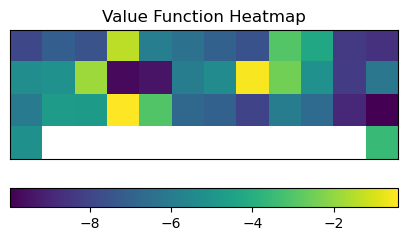

In [12]:
policy = np.random.choice(4, size=48)  # Random policy for demonstration
V = np.random.rand(48) * -10  # Random value function for demonstration
print_policy(policy)
print_value_function(V)

In [13]:
# Define a Policy Evaluation function
# ---> brute force approximation
def policy_evaluation(env, policy, theta=1e-6, discount_factor=0.99):
    """This function takes a policy and an environment and returns the
    value function for that policy.
    Args:
        env: The environment to evaluate the policy on.
        policy: The policy to evaluate. [nS x nA] shaped matrix
        theta: We stop evaluation once our value function change is less than theta for all states.
        discount_factor: Gamma discount factor.
    """
    V = np.zeros(env.nS)
    while True:
        delta = 0 # Variable that tracks the maximum change in the value function
        #for s in range(env.nS):
            ### the policy evaluation function
        new_V = np.sum(policy*np.sum(env.P*(env.R + discount_factor * V), axis=2), axis=1)
        delta=np.abs(new_V-V)
        if np.all(delta < theta): # ---> check this detail?
            break
        V=new_V
    return V

Remember what a value function represents

$$V^\pi(s) = \mathbb{E}_\pi \left[ \sum_{t=0}^{\infty} \gamma^t r_t \mid s_0 = s \right]$$

It is the expected cumulative reward starting from state $s$ and following policy $\pi$.
It can be computed iteratively using the Bellman expectation equation:
$$V^\pi(s) = \sum_{a} \pi(a|s) \sum_{s', r} p(s'| s, a) \left[ r(s, a, s') + \gamma V^\pi(s') \right]$$

With ```policy_evaluation``` function we can evaluate stochastic policies where the action taken in each state is not deterministic.

$$\pi(a|s) = \Pr(A_t = a | S_t = s)$$

Let's test a uniform random policy in the cliff environment.

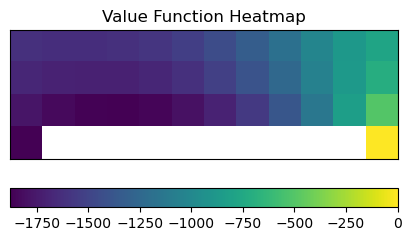

0.15231680870056152


In [14]:
policy = np.ones((48, 4))  # Uniform random policy
policy = policy / policy.sum(axis=1, keepdims=True)  # Normalize to get probabilities
start=time.time()
V = policy_evaluation(SimpleCliffEnv(), policy)
end=time.time()
print_value_function(V)
print(end-start)
# ---> vectorized is 50x faster (swag)

We can notice that the value function is very low in states close to the cliff, as the agent is likely to fall off and incur a large negative reward. 
The value function increases as we move away from the cliff, indicating that the agent is more likely to reach the goal without falling off.

### Q-Learning Agent
Now let's implement and test a Q-Learning agent in the cliff environment. Q-Learning is an off-policy algorithm that learns the optimal action-value function, which can be used to derive the optimal policy.

Q value function:
$$Q^*(s, a) = \mathbb{E} \left[ r_t + \gamma \max_{a'} Q^*(s_{t+1}, a') \mid s_t = s, a_t = a \right]$$

Update rule:
$$Q(s, a) \gets Q(s, a) + \alpha \left( r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s, a) \right)$$

To explore the action space we use an epsilon-greedy policy, which selects a random action with probability epsilon, and the action that maximizes the Q-value with probability 1-epsilon.

$$ \pi(a|s) = \begin{cases} \frac{\epsilon}{|A(s)|} & \text{if } a \neq \arg\max_{a'} Q(s, a') \\ 1 - \epsilon + \frac{\epsilon}{|A(s)|} & \text{if } a = \arg\max_{a'} Q(s, a') \end{cases} $$

In [18]:
s=rng.choice(4) 
print(s)

3


In [20]:
# Q Learning Implementation
# With epsilon-greedy action selection
class QLearningAgent:
    def __init__(self, env, learning_rate=0.1, discount_factor=0.99, exploration_prob=0.1):
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = exploration_prob
        self.Q = np.zeros((env.nS, env.nA))

    def choose_action(self, state):
        ### An epsilon-greedy policy (the function should return a valid action index)
        # ---> NB the simple idea of this:
        prob=rng.uniform()
        if (prob<self.epsilon):
            res=rng.choice(self.env.nA) # ---> NB Generator.choice returns a number in range(argument:int)
        else:
            res=np.argmax(self.Q[state]) # ---> NB Q is essentially a value function
        return res

    def learn(self, state, action, reward, next_state): 
        ### Update the Q-value table following the Q-learning algorithm
        # ---> (NB one step only)
        self.Q[state,action] = self.Q[state,action] + self.lr * (reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state,action])

In [21]:
# ---> review details of these?
def get_greedy_policy(Q):
    policy = np.zeros(Q.shape[0], dtype=int)
    for s in range(Q.shape[0]):
        policy[s] = np.argmax(Q[s])
    return policy

def get_max_q_values(Q):
    V = np.max(Q, axis=1)
    return V

def training_loop(env, agent, num_episodes=500):
    for episode in range(num_episodes):
        if episode % 200 == 0:
            policy = get_greedy_policy(agent.Q)
            print_policy(policy)
            V = get_max_q_values(agent.Q)
            print_value_function(V)
        state = 36  # Start state
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state_probs = env.P[state, action]
            next_state = np.random.choice(np.arange(env.nS), p=next_state_probs)
            reward = env.R[state, action, next_state]
            agent.learn(state, action, reward, next_state)
            state = next_state
            if state == 47:  # Goal state
                done = True

Test the Q-Learning agent in the cliff environment for 1000 episodes.

 ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑  
 ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑  
 ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑   ↑  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


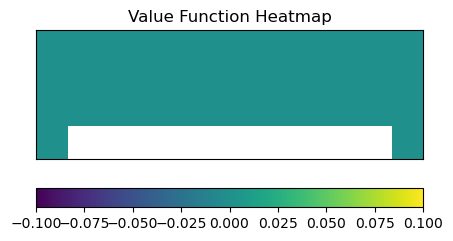

 ←   ↑   →   →   ↑   ←   ↓   →   →   →   ↓   ↓  
 ↑   →   →   →   →   →   ↓   →   →   →   ↓   ↓  
 ↓   →   ←   →   →   ↑   →   →   →   →   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


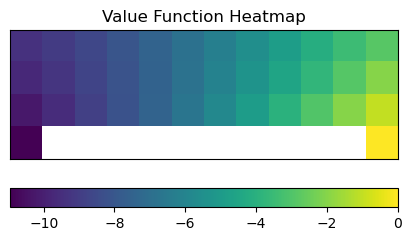

 →   ↓   →   →   →   →   →   →   →   →   →   ↓  
 ↓   →   →   →   →   →   →   ←   →   ↓   ↓   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


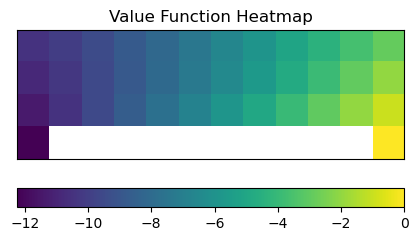

 ←   →   →   →   →   ↓   →   →   →   →   →   ↓  
 ←   →   →   →   →   →   →   →   →   →   ↓   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


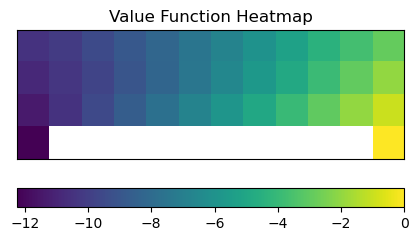

 ↑   ↑   →   →   ←   ↑   →   →   ↓   →   →   ↓  
 →   →   →   →   →   →   →   ↓   →   ↓   ↓   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


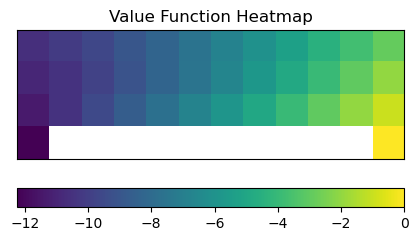

 ←   ←   ↓   ←   →   →   →   →   ↓   →   →   ↓  
 ↑   →   →   →   →   ↓   →   →   →   →   ↓   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


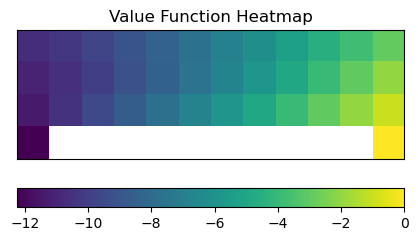

In [22]:
q_agent = QLearningAgent(SimpleCliffEnv(), exploration_prob=0.1)
num_episodes = 1000

training_loop(SimpleCliffEnv(), q_agent, num_episodes)
policy = get_greedy_policy(q_agent.Q)
print_policy(policy)
V = get_max_q_values(q_agent.Q)
print_value_function(V)


# SARSA Agent
Now let's implement and test a SARSA agent in the cliff environment. SARSA is an on-policy algorithm that learns the action-value function for the policy being followed.
SARSA value function:
$$Q^\pi(s, a) = \mathbb{E}_\pi \left[ r_t + \gamma Q^\pi(s_{t+1}, a_{t+1}) \mid s_t = s, a_t = a \right]$$

Update rule:
$$Q(s, a) \gets Q(s, a) + \alpha \left( r_t + \gamma Q(s_{t+1}, a_{t+1}) - Q(s, a) \right)$$

In [23]:
# SARSA Implementation
class SARSAAgent:
    def __init__(self, env, learning_rate=0.1, discount_factor=0.99, exploration_prob=0.1):
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = exploration_prob
        self.Q = np.zeros((env.nS, env.nA))

    def choose_action(self, state):
        ### An epsilon-greedy policy (the function should return a valid action index) --- same as before
        prob=rng.uniform()
        if (prob<self.epsilon):
            res=rng.choice(self.env.nA) # ---> NB Generator.choice returns a number in range(argument:int)
        else:
            res=np.argmax(self.Q[state]) # ---> NB Q is essentially a value function
        return res


    def learn(self, state, action, reward, next_state, next_action):
        ### TODO Update the Q-value table following the SARSA algorithm (remember the difference with Q-learning!)
         self.Q[state,action] = self.Q[state,action] + self.lr * (reward + self.gamma * self.Q[next_state, next_action] - self.Q[state,action])
        
# ---> review from this till the end?:
def sarsa_training_loop(env, agent, num_episodes=500):
    for episode in range(num_episodes):
        state = 36  # Start state
        action = agent.choose_action(state)
        done = False
        while not done:
            next_state_probs = env.P[state, action]
            next_state = np.random.choice(np.arange(env.nS), p=next_state_probs)
            reward = env.R[state, action, next_state]
            next_action = agent.choose_action(next_state)
            agent.learn(state, action, reward, next_state, next_action)
            state = next_state
            action = next_action
            if state == 47:  # Goal state
                done = True

 →   →   →   →   →   →   →   →   →   →   →   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 ↑   ↑   →   ↑   →   →   ↑   ↑   ←   ↑   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


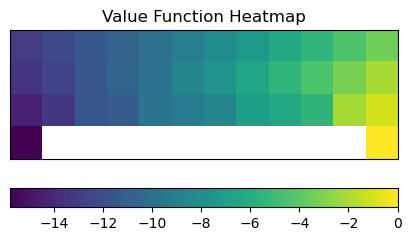

In [24]:
# Test SARSA Agent
sarsa_agent = SARSAAgent(SimpleCliffEnv(), exploration_prob=0.1)
sarsa_training_loop(SimpleCliffEnv(), sarsa_agent, num_episodes=1000)
policy = get_greedy_policy(sarsa_agent.Q)
print_policy(policy)
V = get_max_q_values(sarsa_agent.Q)
print_value_function(V)

We can notice that the value function learned by the SARSA agent is generally lower than that of the Q-Learning agent, especially in states close to the cliff. This is because SARSA takes into account the action taken in the next state, which may lead to falling off the cliff, while Q-Learning always assumes the best possible action will be taken. As a result, SARSA tends to be more conservative in its value estimates, leading to a safer policy that avoids risky actions near the cliff.

 →   →   →   →   →   →   →   →   →   →   →   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 →   →   →   →   →   →   →   →   →   →   →   ↓  
 ↑   C   C   C   C   C   C   C   C   C   C   G  


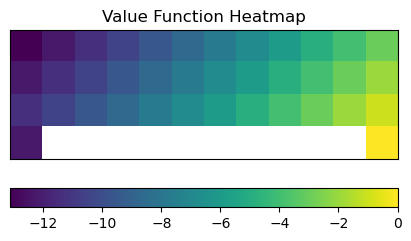

In [25]:
# Compare with values of an optimal policy
optimal_policy = np.zeros(48, dtype=int)
for s in range(48):
    if s < 36:
        optimal_policy[s] = 1  
    elif s >= 36 and s < 47:
        optimal_policy[s] = 0 
    if s % 12 == 11:
        optimal_policy[s] = 2 
print_policy(optimal_policy)
policy = np.eye(4)[optimal_policy] # One-hot encoding to get [nS x nA] shape
optimal_V = policy_evaluation(SimpleCliffEnv(), policy)
print_value_function(optimal_V)

In [28]:
# -----------------------------------> ends here.

# Policy Gradient Methods
Now that we have tested value-based methods, we can move to policy gradient methods. These methods directly optimize the policy without the need for a value function. We will implement and test the REINFORCE algorithm in the cliff environment.

The REINFORCE algorithm updates the policy parameters in the direction of the gradient of the expected cumulative reward.
The policy gradient is given by:
$$\nabla_\theta J(\theta) = \mathbb{E}_\pi \left[ \nabla_\theta \log \pi_\theta(a|s) G_t \right]$$
where $G_t$ is the cumulative reward from time step $t$:
$$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k}$$

We will consider a linear softmax policy, where the policy parameters are represented as a weight matrix $\theta$.
$$\pi_\theta(a|s) = \frac{e^{\theta_{s,a}}}{\sum_{a'} e^{\theta_{s,a'}}}$$

The gradient of the log-policy is given by:
$$\nabla_\theta \log \pi_\theta(a|s) = \mathbf{1}_{a} - \pi_\theta(\cdot|s)$$
where $\mathbf{1}_{a}$ is a one-hot vector with 1 at the index of action $a$ and 0 elsewhere.


To improve the stability of the learning process, we can introduce a baseline to reduce the variance of the gradient estimates. A common choice for the baseline is the average return or a learned value function. Here, we will use a simple constant baseline.
The baseline is subtracted from the return in the policy gradient update:
$$\nabla_\theta J(\theta) = \mathbb{E}_\pi \left[ \nabla_\theta \log \pi_\theta(a|s) (G_t - b) \right]$$
where $b = V[s]$ is the baseline.

To estimate the baseline, we can use the average return observed during training or a simple heuristic. In this implementation, we will use a constant baseline for simplicity. Here is the value estimation for the baseline:
$$V[s] \gets V[s] + \alpha (G - V[s])$$

In [27]:
# Policy Gradient Methods
import tqdm

class REINFORCEAgent:
    def __init__(self, env, learning_rate=0.01, discount_factor=0.99):
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.policy_params = np.ones((env.nS, env.nA))  # Small random initialization
        self.V = np.zeros(env.nS)  # Value function for baseline

    def get_action_probs(self, state):
        exp_params = np.exp(self.policy_params[state])
        return exp_params / np.sum(exp_params)

    def choose_action(self, state):
        action_probs = self.get_action_probs(state)
        return np.random.choice(self.env.nA, p=action_probs)

    def update_policy(self, episode):
        G = 0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = reward + self.gamma * G
            action_probs = self.get_action_probs(state)
            grad_log_policy = -action_probs
            grad_log_policy[action] += 1
            self.policy_params[state] += self.lr * (G - self.V[state]) * grad_log_policy
            #self.policy_params[state] -= self.policy_params[state].max()  # For numerical stability
            # Update baseline value function
            self.V[state] += self.lr * (G - self.V[state])
        

        
def reinforce_training_loop(env, agent, num_episodes=500):
    for episode_num in tqdm.tqdm(range(num_episodes)):
        episode = []
        state = 36 # Start state
        done = False
        t = 0
        while not done:
            action = agent.choose_action(state)
            next_state_probs = env.P[state, action]
            next_state = np.random.choice(np.arange(env.nS), p=next_state_probs)
            reward = env.R[state, action, next_state]
            episode.append((state, action, reward))
            state = next_state
            if state == 47:  # Goal state
                done = True
            t += 1
            if t > 1000:  # Avoid infinite loops
                break
        agent.update_policy(episode)